In [31]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
#from scipy.special import binom
import pandas as pd
#import math
#import pickle
#import statsmodels.stats.power
import statsmodels.api as sm
#import statsmodels.stats.multitest as mt
#from sklearn import datasets

# Galton dataset

In [32]:
father_son = pd.read_csv('father_son.csv')
father_son.head()

,Unnamed: 0,fheight,sheight
0,1,65.04851,59.77827
1,2,63.25094,63.21404
2,3,64.95532,63.34242
3,4,65.75250,62.79238
4,5,61.13723,64.28113


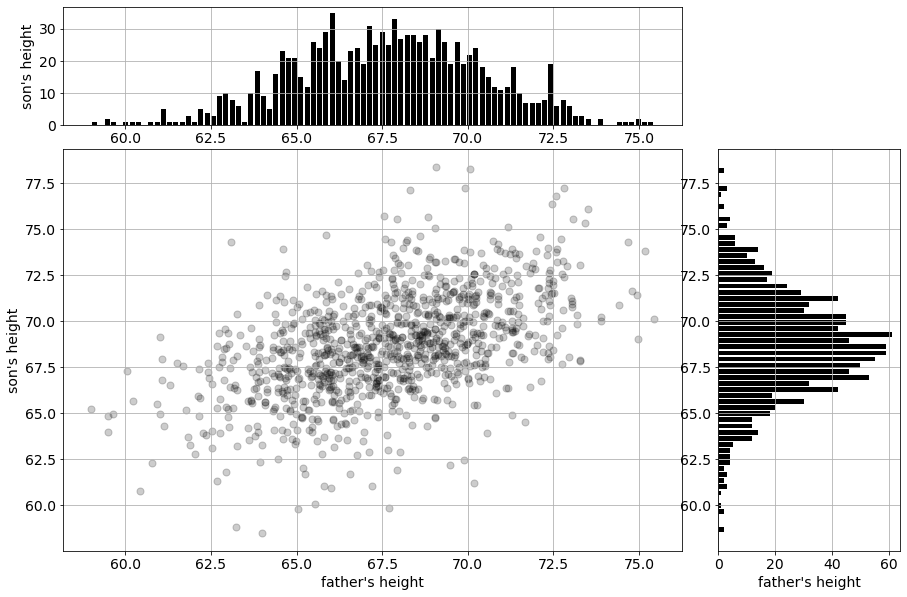

In [33]:
# see https://stackoverflow.com/questions/37008112/matplotlib-plotting-histogram-plot-just-above-scatter-plot

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

plt.rcParams.update({'font.size': 14})

fheight = father_son['fheight'].values
sheight = father_son['sheight'].values

fig = plt.figure(figsize=(15, 10))
gs = gridspec.GridSpec(4, 4)
ax_main = plt.subplot(gs[1:4, :3])
ax_fDist = plt.subplot(gs[0, :3], sharex=ax_main)
ax_sDist = plt.subplot(gs[1:4, 3], sharey=ax_main)

ax_main.scatter(fheight, sheight, c = 'k', alpha = .2, s = 50)
ax_main.set(xlabel = "father's height", ylabel = "son's height")
ax_main.grid(True)

ax_fDist.hist(fheight, bins = 90, align = 'mid', rwidth = 0.8, color = 'k')
ax_fDist.set(ylabel = "son's height")
ax_fDist.grid(True)

ax_sDist.hist(sheight, bins = 60, orientation = 'horizontal', align = 'mid', rwidth = 0.8, color = 'k')
ax_sDist.set(xlabel = "father's height")
ax_sDist.grid(True)

plt.show()

In [34]:
x = np.random.randn(10) + 6
y = x/3 + np.random.randn(10)/1.5 - 2
x1 = np.array(range(11))

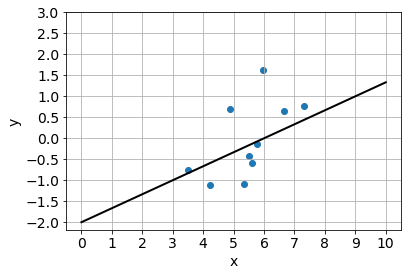

0.5916554104832207


In [35]:
plt.scatter(x, y)
plt.plot(x1, x1/3 - 2, '-', c='k', lw=2)
plt.xticks(x1)
plt.yticks(np.linspace(-2, 3, 11))
plt.xlabel('x')
plt.ylabel('y')
plt.grid()
plt.show()
print(np.corrcoef(x,y)[0,1])

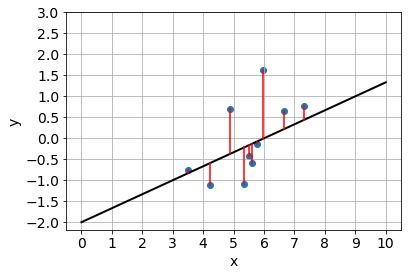

In [36]:
def f(x):
    return x/3 - 2

yf = f(x)
plt.scatter(x, y)
plt.plot(x1, f(x1), '-', c='k', lw=2)
[plt.plot([x[i], x[i]], [y[i], yf[i]], c='r') for i in range(len(x))]

plt.xticks(x1)
plt.yticks(np.linspace(-2, 3, 11))
plt.xlabel('x')
plt.ylabel('y')
plt.grid()
plt.show()

beta0: 33.88660435407791 beta1: 0.5140930386233077
intercept: 33.88660435407803 coefficient: 0.5140930386233065


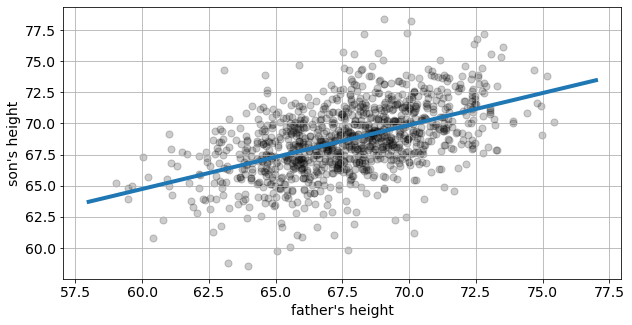

In [37]:
# see https://machinelearningmastery.com/introduction-to-expected-value-variance-and-covariance/

x, y = np.array(fheight), np.array(sheight)
beta1 = np.corrcoef(x, y)[0, 1] * np.std(y)/np.std(x)
beta0 = np.mean(y) - beta1 * np.mean(x)
print('beta0:', beta0, 'beta1:', beta1)

xext = sm.add_constant(x)

lm = sm.OLS(y, xext).fit()
print('intercept:', lm.params[0], 'coefficient:', lm.params[1])

x1 = np.linspace(58, 77, 100)
y1 = beta1 * x1 + beta0

fig, ax = plt.subplots(1, 1, figsize=(10, 5))
ax.scatter(x, y, c='k', alpha = .2, s=50)
ax.plot(x1, y1, lw=4)
ax.set(xlabel="father's height", ylabel="son's height")
ax.grid(True)
plt.show()

# Regresia către medie

In [38]:
x = np.random.randn(10)
ordered = np.argsort(x)[::-1]

y = np.random.randn(10)

# doar in 1 caz din 11 vom obtine un numar mai mic
print(x[ordered[0]], '>', y[ordered[0]])

1.5802822932806901 > 0.5438959030364601


In [39]:
# verificare
# n = 10000000
# x = np.random.randn(n, 10)
# ordered = np.argsort(x, axis=1)
# for i in range(x.shape[0]):
#     x[i, :] = x[i, ordered[i][::-1]]

# y = np.random.randn(n, 10)
# print(np.sum(x[:, 0] < y[:, 0]) / n, 'vs. 1/11 =', 1/11)

rho: 0.501338311172343


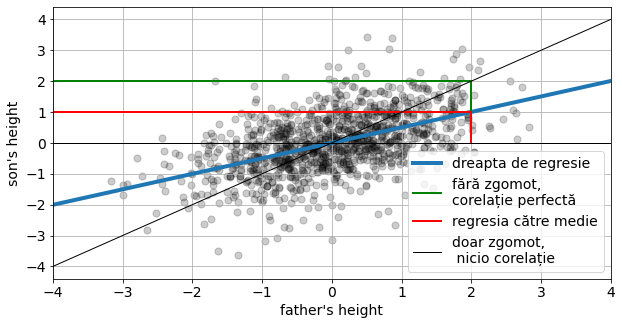

In [40]:
# originea este acum (Xbar, Ybar)
x, y = np.array(fheight), np.array(sheight)
x, y = (x - np.mean(x))/np.std(x), (y - np.mean(y))/np.std(y)
rho = np.corrcoef(x, y)[0, 1]
print('rho:', rho)

x1 = np.linspace(-4, 4, 100)

fig, ax = plt.subplots(1, 1, figsize=(10, 5))
ax.scatter(x, y, c='k', alpha = .2, s=50)
ax.plot(x1, rho * x1, lw=4)
ax.plot([2, 2, -4], [0, 2, 2], 'g', lw=2)
ax.plot([2, 2, -4], [0, 1, 1], 'r', lw=2)
ax.plot(x1, x1, lw=1, c='k')
ax.plot(x1, [0] * len(x1), lw=1, c='k')
ax.legend(['dreapta de regresie', 'fără zgomot,\ncorelație perfectă', 'regresia către medie', 
           'doar zgomot,\n nicio corelație'])
ax.set(xlabel="father's height", ylabel="son's height", xlim=(-4, 4))
ax.grid(True)
plt.show()

# Laborator

__Q1.__ Considerăm setul $X = \{0.725, 0.429, -0.372, 0.863\}$. Ce valoare a lui $\mu$ minimizează $\sum_i (X_i - \mu)^2$ ? Verificați cu câteva valori în jur.

$S(\mu) = \sum_i (X_i - \mu)^2$

$\min_\mu S(\mu) = \min_\mu \sum_i (X_i - \mu)^2$

$\dfrac{\partial S}{\partial \mu} = -2\sum_i (X_i - \mu) = 0$

$\sum_i X_i - n\mu = 0$

$\mu = \dfrac{1}{n}\sum_i X_i$

In [41]:
x = [0.725, 0.429, -0.372, 0.863]
mu = np.mean(x)
print('Valoarea care minimizează S este: ', mu)

Valoarea care minimizează S este:  0.41125


__Q2.__ Pentru problema anterioară, considerăm că se dă un set de ponderi $w = \{2, 2, 1, 1\}$. Dorim să minimizăm suma $\sum_i w_i(X_i - \mu)^2$. Ce valoare pentru $\mu$ obținem?

$S(\mu) = \sum_i w_i(X_i - \mu)^2$

$\min_\mu S(\mu) = \min_\mu \sum_i w_i(X_i - \mu)^2$

$\dfrac{\partial S}{\partial \mu} = -2\sum_i w_i(X_i - \mu) = 0$

$\sum_i w_iX_i - \mu\sum_i w_i = 0$

$\mu = \dfrac{\sum_i w_iX_i}{\sum_i w_i}$

In [42]:
w = [2, 2, 1, 1]
mu = np.sum(w[i] * x[i] for i in range(len(x))) / np.sum(w)
print('Valoarea care minimizează S este: ', mu)

Valoarea care minimizează S este:  0.46649999999999997


C:\Users\Cristi\AppData\Local\Temp/ipykernel_46668/264479882.py:2: DeprecationWarning: Calling np.sum(generator) is deprecated, and in the future will give a different result. Use np.sum(np.fromiter(generator)) or the python sum builtin instead.
  mu = np.sum(w[i] * x[i] for i in range(len(x))) / np.sum(w)


__Q3.__ Pentru setul Galton (fathers.sons):

__a)__ găsiți media, deviația standard și corelația dintre înălțimile părinților și cele ale fiilor.

In [43]:
fheight = father_son['fheight'].values
sheight = father_son['sheight'].values

mu_fheight = np.mean(fheight)
std_fheight = np.std(fheight)
print('Media înălţimii taţilor: ', mu_fheight)
print('Deviaţia standard pentru înălţimile taţilor: ', std_fheight)

mu_sheight = np.mean(sheight)
std_sheight = np.std(sheight)
print('Media înălţimii fiilor: ', mu_sheight)
print('Deviaţia standard pentru înălţimile fiilor: ', std_sheight)

corr_heights = np.corrcoef(fheight, sheight)[0, 1]
print('Corelaţia dintre înălţimile părinţilor şi cele ale fiilor: ', corr_heights)

Media înălţimii taţilor:  67.68709686456401
Deviaţia standard pentru înălţimile taţilor:  2.743594987591043
Media înălţimii fiilor:  68.68406965677178
Deviaţia standard pentru înălţimile fiilor:  2.8133957698626495
Corelaţia dintre înălţimile părinţilor şi cele ale fiilor:  0.5013383111723433


__b)__ centrați variabilele pentru fii și părinți și verificați că variabilele centrate au media 0.

In [44]:
fheight = father_son['fheight'].values
sheight = father_son['sheight'].values

fheight -= mu_fheight
print('Media înălţimii taţilor: ', np.mean(fheight))

sheight -= mu_sheight
print('Media înălţimii fiilor: ', np.mean(sheight))

Media înălţimii taţilor:  -4.4557225359353225e-15
Media înălţimii fiilor:  1.6821011703708494e-14


__c)__ realizați același lucru pentru deviația standard și verificați că ea devine 1.

In [45]:
fheight /= std_fheight

std_fheight = np.std(fheight)
print('Deviaţia standard pentru înălţimile taţilor:', std_fheight)

sheight /= std_sheight

std_sheight = np.std(sheight)
print('Deviaţia standard pentru înălţimile fiilor:', std_sheight)

Deviaţia standard pentru înălţimile taţilor: 1.0
Deviaţia standard pentru înălţimile fiilor: 1.0


__d)__ realizați procedura completă de normalizare (centrare + scalare) și verificați $N(0, 1)$.

In [46]:
fheight = father_son['fheight'].values
sheight = father_son['sheight'].values

fheight = [(x - np.mean(fheight)) / np.std(fheight) for x in fheight]
print('Media înălţimii taţilor: ', np.mean(fheight))
print('Deviaţia standard pentru înălţimile taţilor:', np.std(fheight))

sheight = [(x - np.mean(sheight)) / np.std(sheight) for x in sheight]
print('Media înălţimii fiilor: ', np.mean(sheight))
print('Deviaţia standard pentru înălţimile fiilor:', np.std(sheight))

Media înălţimii taţilor:  -1.9773916579594624e-17
Deviaţia standard pentru înălţimile taţilor: 1.0
Media înălţimii fiilor:  -1.3182611053063083e-17
Deviaţia standard pentru înălţimile fiilor: 1.0


__Q4.__ Considerăm un dataset pentru care deviația standard a variabilei prezise este dublu față de deviația standard a predictorului său. Variabilele au o corelație de 0.3. Dacă potrivim un model de regresie liniară, care va fi panta estimată?

Prezicem Y pe baza lui X ⇔ $\sigma_Y = 2\sigma_X$

$\beta_1 = Cor(X,Y)\dfrac{\sigma_Y}{\sigma_X} = Cor(X,Y)\dfrac{2\sigma_X}{\sigma_X} = 2Cor(X, Y)$

In [47]:
corr = 0.3
beta_1 = 2 * corr
print('Panta estimată: ', beta_1)

Panta estimată:  0.6


__Q5.__ Pentru problema anterioară, variabila prezisă are o medie 1 iar predictorul o medie de 0.5. Care este intercept-ul?

$\beta_0 = \overline{Y} - \beta_1\overline{X}$

In [48]:
mu_y = 1
mu_x = 0.5
print('Intercept-ul: ', mu_y - beta_1 * mu_x)

Intercept-ul:  0.7


__Q6.__ Avem două cântare care au asociat zgomot, și mai mulți oameni pe care vrem să-i cântărim. Vom cântări fiecare persoană pe ambele cântare. Corelația este de 0.75. Fiecare set de măsurători este normalizat. Masa cuiva este la 2 deviații standard peste medie în primul grup de cântăriri. La câte deviații standard față de medie estimăm că este masa corespondentă în al doilea grup?

In [49]:
corr = 0.75
mu_x, std_x, mu_y, std_y = 0, 1, 0, 1

beta_1 = corr * std_y / std_x
beta_0 = mu_y - beta_1 * mu_x

mass = 2

print(beta_0 + beta_1 * mass)

1.5


__Q7.__ Considerăm următorul dataset, în care încercăm să prezicem Y pe baza lui X:

In [50]:
x = [8.63, 11.23, 9.73, 11.89, 10.25, 14.12, 11.24, 13.59, 13.86, 13.09, 12.05, 13.46, 13.45, 12.71, 15.08, 14.93,
     14.6, 15.73, 15.39, 16.37, 17.65, 15.44, 17.62, 17.44, 16.63, 17.23, 19.07, 19.19, 19.71, 18.39, 18.68, 19.09,
     19.71, 20.52, 19.49, 21.85, 20.3, 22.38, 20.81, 20.44, 21.09, 21.85, 22.09, 22.75, 23.8, 21.03, 25.08, 23.51,
     25.67, 25.01]
y = [15.61, 16.89, 17.24, 15.41, 17.03, 16.56, 17.26, 17.84, 20.56, 21.95, 20.54, 18.66, 20.98, 22.22, 22.39, 
     21.91, 22.17, 23.83, 24.19, 24.7, 25.92, 25.78, 23.4, 26.36, 25.68, 26.02, 27.42, 26.92, 27.81, 30.12, 29.2,
     30.63, 28.79, 30.07, 30.94, 32.35, 31.85, 30.93, 32.34, 33.28, 33.02, 32.9, 34.53, 34.57, 34.66, 34.48, 36.12,
     35.53, 37.56, 36.58]

__a)__ determinați media și deviația standard pentru fiecare set X și Y;

In [51]:
mu_x = np.mean(x)
mu_y = np.mean(y)
print(mu_x, mu_y)

std_x = np.std(x)
std_y = np.std(y)
print(std_x, std_y)

17.4984 26.473999999999997
4.321086141238103 6.381005249958662


__b)__ reprezentați printr-un scatterplot Y funcție de X, și pe laturi densitățile de probabilitate pentru X și Y (aveți exemplu mai sus, al treilea frame, sub "Galton dataset");

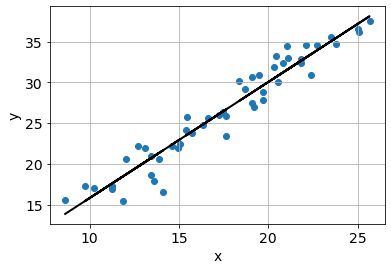

In [52]:
def f(x, a, b):
    return a * x + b

plt.scatter(x, y)
beta_1 = np.corrcoef(x, y)[0, 1] * np.std(y) / np.std(x)
beta_0 = np.mean(y) - beta_1 * np.mean(x)
plt.plot(x, [f(x[i], beta_1, beta_0) for i in range(len(x))], '-', c='k', lw=2)
plt.xlabel('x')
plt.ylabel('y')
plt.grid()
plt.show()

__c)__ determinați coeficientul de corelație dintre cele două seturi;

In [53]:
n = len(x)
mu_x = np.mean(x)
mu_y = np.mean(y)
print('n=%d, mean_x=%f, mean_y=%f' % (n, mu_x, mu_y))

std_x = np.std(x)
std_y = np.std(y)
print('std_x=%f, std_y=%f' % (std_x, std_y))

cov = 1/n * ((np.sum(x[i] * y[i] for i in range(n)) - n * mu_x * mu_y))
corr = cov / (std_x * std_y)
print(corr)
print('Coeficientul de corelaţie dintre x şi y: ', np.corrcoef(x, y)[0, 1])

n=50, mean_x=17.498400, mean_y=26.474000
std_x=4.321086, std_y=6.381005
0.9638387722596944
Coeficientul de corelaţie dintre x şi y:  0.9638387722596928


C:\Users\Cristi\AppData\Local\Temp/ipykernel_46668/443930955.py:10: DeprecationWarning: Calling np.sum(generator) is deprecated, and in the future will give a different result. Use np.sum(np.fromiter(generator)) or the python sum builtin instead.
  cov = 1/n * ((np.sum(x[i] * y[i] for i in range(n)) - n * mu_x * mu_y))


__d)__ 'fabricați' două seturi de date pentru care coeficientul de corelație să vă dea zero (sau cât mai apropiat de zero); reprezentați într-un scatter plot;

Coeficientul de corelaţie dintre x şi y:  -0.00209815286072739


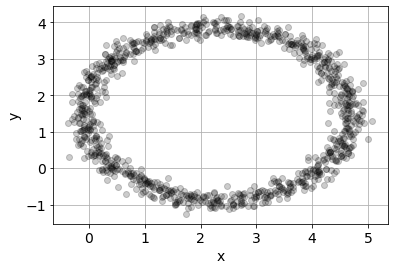

In [54]:
t = np.linspace(0, 2 * np.pi, 1000)
xc = 3 * np.random.rand()
yc = 3 * np.random.rand()
r = 2 * np.random.rand() + 0.5

x = r * np.cos(t) + np.random.normal(scale = 1.0 / 7, size = len(t)) + xc
y = r * np.sin(t) + np.random.normal(scale = 1.0 / 7, size = len(t)) + yc

print('Coeficientul de corelaţie dintre x şi y: ', np.corrcoef(x, y)[0, 1])

plt.plot(x, y, 'o', c='k', alpha=0.2)
plt.xlabel('x')
plt.ylabel('y')
plt.grid()
plt.show()

__e)__ 'fabricați' două seturi de date pentru care coeficientul de corelație să vă dea 1, fără ca seturile să fie identice; reprezentați într-un scatter plot;

$Cor(X,Y) = 1$ dacă $Y = aX + b$, unde $a = \dfrac{\sigma_Y}{\sigma_X}$

std_x / std_y = a = 2.0
Coeficientul de corelaţie dintre x şi y:  1.0


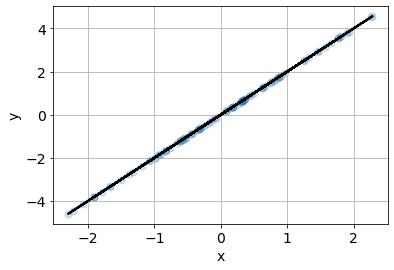

In [55]:
def f(x, a, b):
    return a * x + b

x = np.random.randn(100)
y = [f(x[i], 2, 0) for i in range(100)]

std_x = np.std(x)
std_y = np.std(y)
print('std_x / std_y = a =', std_y / std_x)
print('Coeficientul de corelaţie dintre x şi y: ', np.corrcoef(x, y)[0, 1])

plt.scatter(x, y, alpha=0.2, s=50)
plt.plot(x, f(x, 2, 0), '-', c='k', lw=2)
plt.xlabel('x')
plt.ylabel('y')
plt.grid()
plt.show()

__f)__ determinați corelația pentru problema inițială, precum și intercept-ul. Calculați dreapta de regresie prin cele două metode (manual și cu metoda statmodels.OLS), și reprezentați-o.

Corelaţia:  1.4233135061132112
Intercept-ul:  1.5682909446285827
Corelaţia: 1.4233135061132103
Intercept-ul:  1.5682909446285993


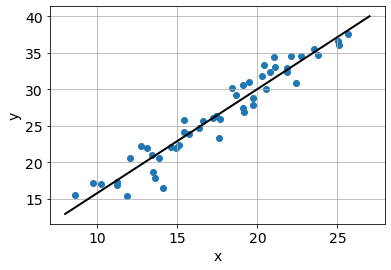

In [56]:
x = [8.63, 11.23, 9.73, 11.89, 10.25, 14.12, 11.24, 13.59, 13.86, 13.09, 12.05, 13.46, 13.45, 12.71, 15.08, 14.93,
     14.6, 15.73, 15.39, 16.37, 17.65, 15.44, 17.62, 17.44, 16.63, 17.23, 19.07, 19.19, 19.71, 18.39, 18.68, 19.09,
     19.71, 20.52, 19.49, 21.85, 20.3, 22.38, 20.81, 20.44, 21.09, 21.85, 22.09, 22.75, 23.8, 21.03, 25.08, 23.51,
     25.67, 25.01]
y = [15.61, 16.89, 17.24, 15.41, 17.03, 16.56, 17.26, 17.84, 20.56, 21.95, 20.54, 18.66, 20.98, 22.22, 22.39, 
     21.91, 22.17, 23.83, 24.19, 24.7, 25.92, 25.78, 23.4, 26.36, 25.68, 26.02, 27.42, 26.92, 27.81, 30.12, 29.2,
     30.63, 28.79, 30.07, 30.94, 32.35, 31.85, 30.93, 32.34, 33.28, 33.02, 32.9, 34.53, 34.57, 34.66, 34.48, 36.12,
     35.53, 37.56, 36.58]

beta_1 = np.corrcoef(x, y)[0, 1] * np.std(y) / np.std(x)
beta_0 = np.mean(y) - beta_1 * np.mean(x)

print('Corelaţia: ', beta_1)
print('Intercept-ul: ', beta_0)

xext = sm.add_constant(x)
lm = sm.OLS(y, xext).fit()
print('Corelaţia:', lm.params[1])
print('Intercept-ul: ', lm.params[0])

x1 = np.linspace(8, 27, 100)
y1 = beta_1 * x1 + beta_0

plt.scatter(x, y)
plt.plot(x1, y1, '-', c='k', lw=2)
plt.xlabel('x')
plt.ylabel('y')
plt.grid()
plt.show()

__Q8.__ Folosiți setul mtcars.csv. Realizați o regresie liniară cu consumul (miles per gallon) ca variabilă prezisă pe baza puterii motorului (horsepower). Realizați scatter plot-ul și trasați dreapta de regresie. Care este eroarea pătratică medie (RMS) dintre valorile de consum reale și valorile prezise?

In [57]:
mtcars = pd.read_csv('mtcars.csv')
mtcars.head()

,Unnamed: 0,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
0,Mazda RX4,21.0,6,160.0,110,3.90,2.620,16.46,0,1,4,4
1,Mazda RX4 Wag,21.0,6,160.0,110,3.90,2.875,17.02,0,1,4,4
2,Datsun 710,22.8,4,108.0,93,3.85,2.320,18.61,1,1,4,1
3,Hornet 4 Drive,21.4,6,258.0,110,3.08,3.215,19.44,1,0,3,1
4,Hornet Sportabout,18.7,8,360.0,175,3.15,3.440,17.02,0,0,3,2


Corelaţia:  -0.06822827807156367
Intercept-ul:  30.098860539622493
Corelaţia: -0.06822827807156367
Intercept-ul:  30.098860539622514


D:\Anaconda\lib\site-packages\statsmodels\tsa\tsatools.py:142: FutureWarning: In a future version of pandas all arguments of concat except for the argument 'objs' will be keyword-only
  x = pd.concat(x[::order], 1)


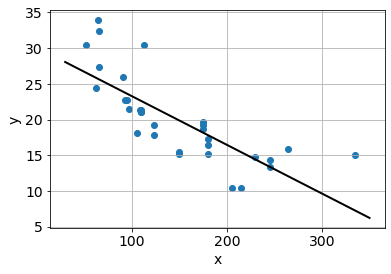

In [58]:
x = mtcars['hp']
y = mtcars['mpg']

beta_1 = np.corrcoef(x, y)[0, 1] * np.std(y) / np.std(x)
beta_0 = np.mean(y) - beta_1 * np.mean(x)

print('Corelaţia: ', beta_1)
print('Intercept-ul: ', beta_0)

xext = sm.add_constant(x)
lm = sm.OLS(y, xext).fit()
print('Corelaţia:', lm.params[1])
print('Intercept-ul: ', lm.params[0])

x1 = np.linspace(30, 350, 100)
y1 = beta_1 * x1 + beta_0

plt.scatter(x, y)
plt.plot(x1, y1, '-', c='k', lw=2)

plt.xlabel('x')
plt.ylabel('y')
plt.grid()
plt.show()

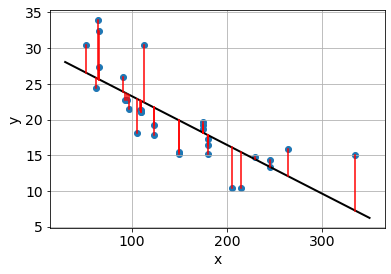

In [59]:
plt.scatter(x, y)
plt.plot(x1, y1, '-', c='k', lw=2)
[plt.plot([x[i], x[i]], [y[i], beta_0 + beta_1 * x[i]], c='r') for i in range(len(x))]

plt.xlabel('x')
plt.ylabel('y')
plt.grid()
plt.show()

In [60]:
rms = np.sum(((y[i] - (beta_0 + beta_1 * x[i]))**2) for i in range(len(x)))
print('Eroarea pătratică medie: ', rms)

Eroarea pătratică medie:  447.6743135446018


C:\Users\Cristi\AppData\Local\Temp/ipykernel_46668/1026336269.py:1: DeprecationWarning: Calling np.sum(generator) is deprecated, and in the future will give a different result. Use np.sum(np.fromiter(generator)) or the python sum builtin instead.
  rms = np.sum(((y[i] - (beta_0 + beta_1 * x[i]))**2) for i in range(len(x)))
